## More pandas

In [1]:
import numpy as np
import pandas as pd


## Using rank

In [2]:
rowdata = {'col1': [414, 651], 'col2': [715, 612]}
areacodes = pd.DataFrame(rowdata, index =['WI','MN'])
areacodes['col3'] = [262, 218]
print(areacodes)                                       

    col1  col2  col3
WI   414   715   262
MN   651   612   218


In [3]:
print(areacodes.rank(axis='columns'))

    col1  col2  col3
WI   2.0   3.0   1.0
MN   3.0   2.0   1.0


In [4]:
print(areacodes.rank(axis='rows'))

    col1  col2  col3
WI   1.0   2.0   2.0
MN   2.0   1.0   1.0


In [5]:
veg = areacodes
veg.columns = ['beets','carrots','cabbage'] # how many bushels of vegetables
veg

,beets,carrots,cabbage
WI,414,715,262
MN,651,612,218


In [6]:
# back to rank

veg['beets'].rank()

WI    1.0
MN    2.0
Name: beets, dtype: float64

In [7]:
veg_rank = veg[['beets','carrots']].rank(axis='columns')
veg_rank

,beets,carrots
WI,1.0,2.0
MN,2.0,1.0


In [8]:
## Mergind DataFrame

In [9]:
veg # not making in place changes unless we specify that attribute

,beets,carrots,cabbage
WI,414,715,262
MN,651,612,218


In [10]:
# typically you want to merge DataFrames on a column that they have in common

In [11]:
veg_composite2 = pd.merge(veg, veg_rank, left_index = True, right_index = True)
veg_composite2

,beets_x,carrots_x,cabbage,beets_y,carrots_y
WI,414,715,262,1.0,2.0
MN,651,612,218,2.0,1.0


In [12]:
# you cant have two column names that are named the same thing. 
# merge function will handle for you if you dont handle it yourself and will add either 
# "x" or "y" in this scenerio it didnt mess with cabbage because cabbage wasnt a duplicate.

## Working with matploblib

In [13]:
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


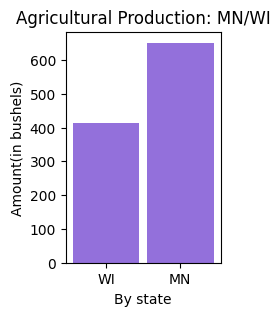

In [22]:
# bar graph 
# show comparison of WI and MN, could be two different colors
# numbers to compare on y axis, and states on x axis
# just the beets, carrots and cabbage but not the top producers

plt.figure(figsize=(2,3)) #will give width first then height

plt.title("Agricultural Production: MN/WI")
plt.xlabel("By state")
plt.ylabel("Amount(in bushels)")

plt.bar(
    veg_composite2.index,
    veg_composite2['beets_x'],
    color='mediumpurple',
    width= .9
)
# you are able to seperate parameters using commas for visual organizations 

plt.show()    # .show () is the print of matplotlib

In [18]:
# keep in mind that you could be sending to someone who is viewing this
# graph for the very first time and there are no specifics on beets in above graph

In [23]:
# plt.plot(
   # veg_composite2.index,
   # veg_composite2['beets_x']
#)

#plt.show() 
# Line chart using plot() does not make sense here

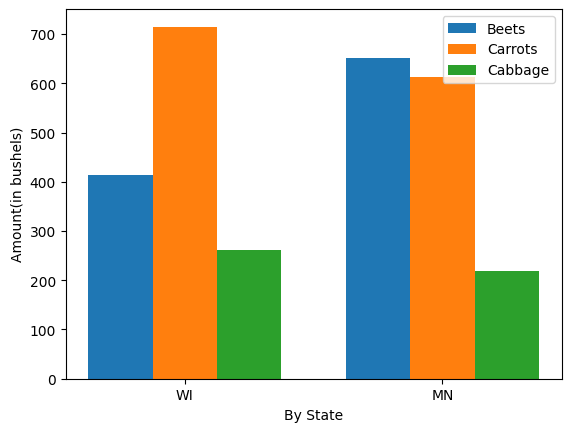

In [30]:
x = np.arange(len(veg_composite2.index)) # The length of the index for our DataFrame which is [0,1]
width = 0.25
fig, ax = plt.subplots()

ax.bar(x - width, veg_composite2['beets_x'], width, label='Beets')
ax.bar(x, veg_composite2['carrots_x'], width, label='Carrots')
ax.bar(x + width, veg_composite2['cabbage'], width, label='Cabbage')

ax.set_xlabel("By State")
ax.set_ylabel("Amount(in bushels)")
ax.set_xticks(x)
ax.set_xticklabels(veg_composite2.index)
ax.legend()

plt.show()